<a href="https://colab.research.google.com/github/UjjvalDE/AI/blob/main/Copy_of_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


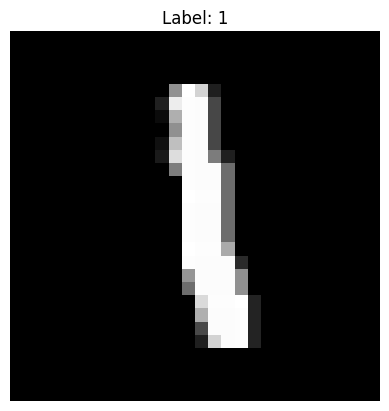

In [4]:
plt.imshow(X_train[6], cmap="gray")
plt.title(f"Label: {y_train[6]}")
plt.axis("off")
plt.show()


In [5]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [6]:
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)
print("Flattened train shape:", X_train.shape)
print("Flattened test shape :", X_test.shape)


Flattened train shape: (60000, 784)
Flattened test shape : (10000, 784)


In [7]:
def build_mlp(activation_hidden):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation=activation_hidden),
        tf.keras.layers.Dense(128, activation=activation_hidden),
        tf.keras.layers.Dense(64,  activation=activation_hidden),
        tf.keras.layers.Dense(64,  activation=activation_hidden),
        tf.keras.layers.Dense(32,  activation=activation_hidden),
        tf.keras.layers.Dense(32,  activation=activation_hidden),
        tf.keras.layers.Dense(10,  activation='softmax')  # 10 classes, probability distribution
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
model_sigmoid = build_mlp('sigmoid')
print("Model with Sigmoid hidden layers:")
model_sigmoid.summary()

history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_sig, test_acc_sig = model_sigmoid.evaluate(X_test, y_test, verbose=0)
print(f"[Sigmoid] Test accuracy: {test_acc_sig:.4f}, Test loss: {test_loss_sig:.4f}")


Model with Sigmoid hidden layers:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2103 - loss: 2.1424 - val_accuracy: 0.6112 - val_loss: 1.1819
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6178 - loss: 1.0819 - val_accuracy: 0.6980 - val_loss: 0.8394
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7118 - loss: 0.7903 - val_accuracy: 0.8171 - val_loss: 0.6594
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8150 - loss: 0.5929 - val_accuracy: 0.8636 - val_loss: 0.4526
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8669 - loss: 0.4128 - val_accuracy: 0.9029 - val_loss: 0.3614
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9221 - loss: 0.3148 - val_accuracy: 0.9333 - val_loss: 0.2768
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9494 - loss: 0.2270 - val_accuracy: 0.9387 - val_loss: 0.2360
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9573 - loss: 0.1820 - val_accuracy:

In [9]:
model_tanh = build_mlp('tanh')
print("Model with Tanh hidden layers:")
model_tanh.summary()

history_tanh = model_tanh.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_tanh, test_acc_tanh = model_tanh.evaluate(X_test, y_test, verbose=0)
print(f"[Tanh]    Test accuracy: {test_acc_tanh:.4f}, Test loss: {test_loss_tanh:.4f}")

Model with Tanh hidden layers:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8075 - loss: 0.7409 - val_accuracy: 0.9417 - val_loss: 0.1987
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9496 - loss: 0.1786 - val_accuracy: 0.9524 - val_loss: 0.1622
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9652 - loss: 0.1190 - val_accuracy: 0.9643 - val_loss: 0.1233
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9742 - loss: 0.0854 - val_accuracy: 0.9559 - val_loss: 0.1503
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9779 - loss: 0.0760 - val_accuracy: 0.9693 - val_loss: 0.1085
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9846 - loss: 0.0528 - val_accuracy: 0.9695 - val_loss: 0.1101
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9871 - loss: 0.0434 - val_accuracy: 0.9706 - val_loss: 0.1017
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9890 - loss: 0.0361 - val_accuracy

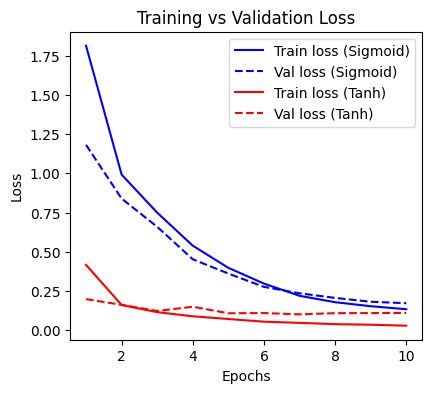

In [10]:
epochs_sig = range(1, len(history_sigmoid.history['loss']) + 1)
epochs_tanh = range(1, len(history_tanh.history['loss']) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_sig, history_sigmoid.history['loss'], 'b-', label='Train loss (Sigmoid)')
plt.plot(epochs_sig, history_sigmoid.history['val_loss'], 'b--', label='Val loss (Sigmoid)')
plt.plot(epochs_tanh, history_tanh.history['loss'], 'r-', label='Train loss (Tanh)')
plt.plot(epochs_tanh, history_tanh.history['val_loss'], 'r--', label='Val loss (Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()


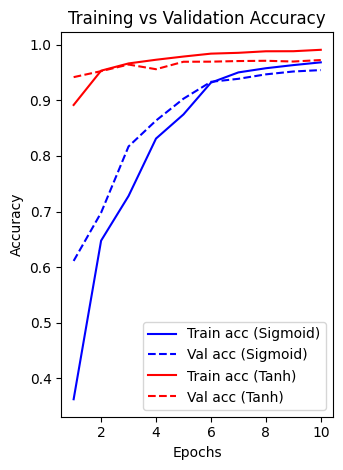

In [11]:
plt.subplot(1, 2, 2)
plt.plot(epochs_sig, history_sigmoid.history['accuracy'], 'b-', label='Train acc (Sigmoid)')
plt.plot(epochs_sig, history_sigmoid.history['val_accuracy'], 'b--', label='Val acc (Sigmoid)')
plt.plot(epochs_tanh, history_tanh.history['accuracy'], 'r-', label='Train acc (Tanh)')
plt.plot(epochs_tanh, history_tanh.history['val_accuracy'], 'r--', label='Val acc (Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:


print("\n" + "="*60)
print("GENERATING RESULTS TABLE")
print("="*60)

rows = []

try:
    rows.append({
        "Model": "Sigmoid (6 FC)",
        "Split": "Training",
        "Accuracy (%)": round(history_sigmoid.history['accuracy'][-1] * 100, 2),
        "Loss": round(history_sigmoid.history['loss'][-1], 4)
    })
    rows.append({
        "Model": "Sigmoid (6 FC)",
        "Split": "Validation",
        "Accuracy (%)": round(history_sigmoid.history['val_accuracy'][-1] * 100, 2),
        "Loss": round(history_sigmoid.history['val_loss'][-1], 4)
    })
    rows.append({
        "Model": "Sigmoid (6 FC)",
        "Split": "Test",
        "Accuracy (%)": round(test_acc_sig * 100, 2),
        "Loss": round(test_loss_sig, 4)
    })

    # Tanh model
    rows.append({
        "Model": "Tanh (6 FC)",
        "Split": "Training",
        "Accuracy (%)": round(history_tanh.history['accuracy'][-1] * 100, 2),
        "Loss": round(history_tanh.history['loss'][-1], 4)
    })
    rows.append({
        "Model": "Tanh (6 FC)",
        "Split": "Validation",
        "Accuracy (%)": round(history_tanh.history['val_accuracy'][-1] * 100, 2),
        "Loss": round(history_tanh.history['val_loss'][-1], 4)
    })
    rows.append({
        "Model": "Tanh (6 FC)",
        "Split": "Test",
        "Accuracy (%)": round(test_acc_tanh * 100, 2),
        "Loss": round(test_loss_tanh, 4)
    })

    # Create table
    results_df = pd.DataFrame(rows)
    results_df = results_df.sort_values(by=["Model", "Split"]).reset_index(drop=True)

    print("\n TABLE GENERATED SUCCESSFULLY:")
    print(results_df.to_string(index=False))


    # Save
    results_df.to_csv('mnist_results_table.csv', index=False)
    print("\n SAVED: mnist_results_table.csv")

except Exception as e:
    print(f"\n ERROR: {e}")
    print("\n TROUBLESHOOTING:")


GENERATING RESULTS TABLE

 TABLE GENERATED SUCCESSFULLY:
         Model      Split  Accuracy (%)   Loss
Sigmoid (6 FC)       Test         95.38 0.1824
Sigmoid (6 FC)   Training         96.82 0.1343
Sigmoid (6 FC) Validation         95.43 0.1726
   Tanh (6 FC)       Test         97.16 0.1042
   Tanh (6 FC)   Training         99.08 0.0293
   Tanh (6 FC) Validation         97.24 0.1108

 SAVED: mnist_results_table.csv


In [13]:
print("\n==== FINAL TEST PERFORMANCE ====")
print(f"Sigmoid -> accuracy: {test_acc_sig:.4f}, loss: {test_loss_sig:.4f}")
print(f"Tanh    -> accuracy: {test_acc_tanh:.4f}, loss: {test_loss_tanh:.4f}")


==== FINAL TEST PERFORMANCE ====
Sigmoid -> accuracy: 0.9538, loss: 0.1824
Tanh    -> accuracy: 0.9716, loss: 0.1042
